# Uso di lenti per la focalizzazione e la collimazione

A cura di Giovanni N. D'Aloisio, matricola 494722, A.A. 2022-23.

##Introduzione

Per una sorgente puntiforme, la legge che descrive l'intensità della radiazione emessa sarebbe $I(x)=A/x^2$, tuttavia la sorgente non è puntiforme. Considerando questo fatto, una ragionevole funzione per l'intensità in funzione della distanza è data da:

$$I(x)=\frac{A}{(x+x_0)^2}$$

Interponendo una lente tra sorgente e rivelatore, si dimostra che vale la legge della lente sottile:

$$\frac{1}{f} = \frac{1}{x} + \frac{1}{y}$$

Con $f$ lunghezza focale della lente, $x$ distanza dell'oggetto e $y$ distanza dell'immagine, entrambe rispetto alla lente. Si noti che esistono diverse convenzioni per quanto riguarda il segno di $y$, per cui è importante conoscere il contesto in cui questa legge viene collocata.


## Scopo dell'esperienza

L’esperienza intende familiarizzare con l’uso delle lenti per manipolare e
propagare a distanza un fascio luminoso.

##Strumentazione

+ 1 LED;
+ 1 fotodiodo;
+ 1 schema di detezione, necessario per avere una risposta lineare;
+ 1 generatore di funzioni in grado di alimentare il LED in onda quadra (per renderne riconoscibile il segnale rispetto alla luce ambiente);
+ 1 oscilloscopio per visualizzare e misurare il segnale;
+ 2 lenti con focale $f = 5$ cm;
+ 2 montaggi per LED/PD, con supporti e connettori;
+ 4 supporti con asta, sostegno di fissaggio e piastra scorrevole;
+ 1 binario lungo 1 m.

## Procedura sperimentale 

Nella prima parte della prova si verifica la legge $I(x)$ mostrata in precedenza, eseguendo un fit per trovare i valori di $A$ e $x_0$.

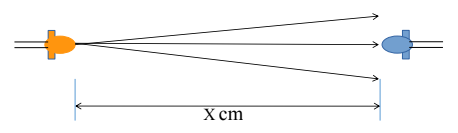

Interponendo la lente, invece, fissato un un valore per $x > 5$ cm si traccia l'intensità della luce in funzione di y, ripetendo la misura con un valore differente di x. In questo modo, per diversi valori di $x = x_i$, si trovano i valori $y_i$ che massimizzano l'intensità della luce. L'insieme di tali coppie di valori $(x_i,y_i)$ può dunque essere fittato con la legge:

$$f=\Bigg( \frac{1}{x+x_0}+\frac{1}{y+y_0} \Bigg)^{-1}$$

dove $x_0$ e $y_0$ sono distanze di offset aventi lo stesso significato della precedente; il fit può essere eseguito esplicitando $x$ o $y$, entrambi noti.

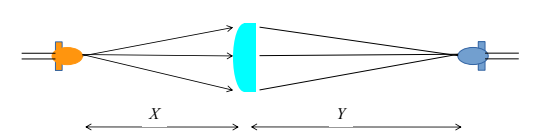

Infine, interponendo una seconda lente tra sorgente e rivelatore, si può ottimizzare la distanza tra tali lenti in modo da avere un fascio il più collimato possibile tra le due lenti, e focalizzato rispetto ai dispositivi optoelettronici utilizzati, e vedere quello che accade variando la distanza tra le lenti, mantenendo le distanze lente-LED e lente-fotodiodo così ottimizzate.

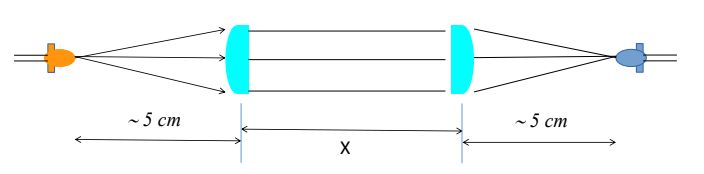


## Importazione e analisi dei dati sperimentali

Di seguito sono riportati gli snippets utilizzati per l'analisi dei dati.

Su [GitHub](https://github.com/nikitodos/UniPV_Physics_Lab_3/tree/main/05_LED_LENS) è possibile visualizzare i dati raccolti in formato tabulato.

### Parte 1 - Nessuna lente

In [ ]:
# Importa librerie di lavoro

import numpy as np
from scipy import optimize as sop
import matplotlib.pyplot as plt
import pandas as pd

# Definisci funzione di fit

def funzione(x,I0,x0):
    I=I0/(x+x0)**2
    return I

# Importa i dati

filename = 'https://github.com/nikitodos/UniPV_Physics_Lab_3/raw/main/05_LED_LENS/NewData/NoLenti.csv'

data = pd.read_csv(filename)

# Converto i dati in numpy arrays, usando unità del S.I.

x=data['Distanza'].to_numpy()
I=data['Intesntità'].to_numpy()

print('Importazione dei dati completata.')

Importazione dei dati completata.


 
Valore fit per l'intensità massima:  I0_fit = ( 1.30e-03 ± 3.3e-05 ) V
Valore fit per offset di distanza:   x0_fit = ( 8.07e-03 ± 4.2e-04 ) m
 


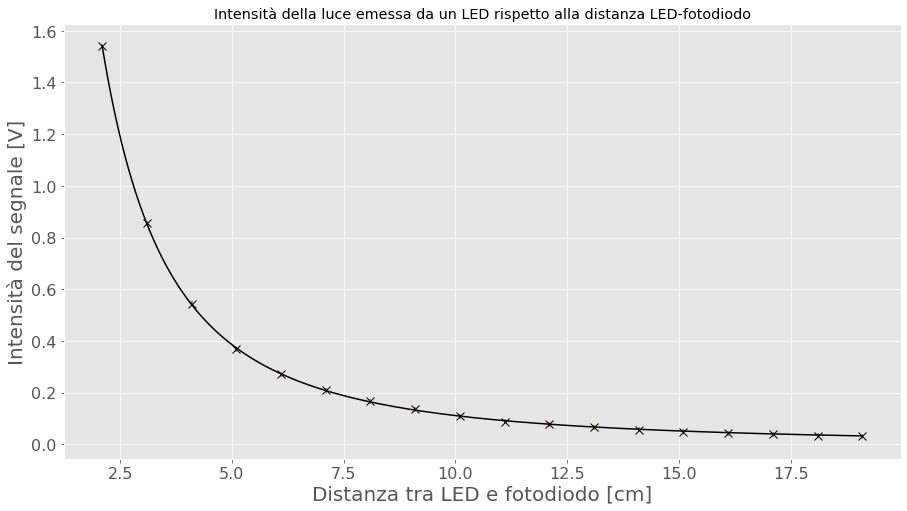

In [ ]:
# Fit dei dati

ndata=len(I)
min=[0, 0]
max=[100000,100000]
bounds=(min,max)
popt, pcov=sop.curve_fit(funzione, x, I, bounds=bounds)
I0_fit = popt[0]
x0_fit = popt[1]
standard_error = np.sqrt(np.diag(pcov))
sigma = np.sqrt(ndata*np.diag(pcov))

print(' ')

print('Valore fit per l\'intensità massima:  I0_fit = (', np.format_float_scientific(I0_fit,precision=2), '±',np.format_float_scientific(sigma[0],precision=1), ") V")
print('Valore fit per offset di distanza:   x0_fit = (', np.format_float_scientific(x0_fit,precision=2), '±',np.format_float_scientific(sigma[1],precision=1), ") m")

print(' ')

# Plot dati fittati più dati reali

plt.figure(figsize=[15,8])
plt.title('Intensità della luce emessa da un LED rispetto alla distanza LED-fotodiodo')
xmin,xmax=x[0],x[ndata-1]
xfit=np.arange(xmin,xmax+1e-5,0.0001)
yfit=funzione(xfit,I0_fit,x0_fit)
plt.xlabel('Distanza tra LED e fotodiodo [cm]', fontsize=20)
plt.ylabel('Intensità del segnale [V]', fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True)
plt.errorbar(x*100,I,yerr=0.01,xerr=0.01,linestyle="")
plt.plot(x*100,I,'x',markersize=8,color="black")
plt.plot(xfit*100,yfit,color="black")
plt.style.use("ggplot")

### Parte 2 - Una lente

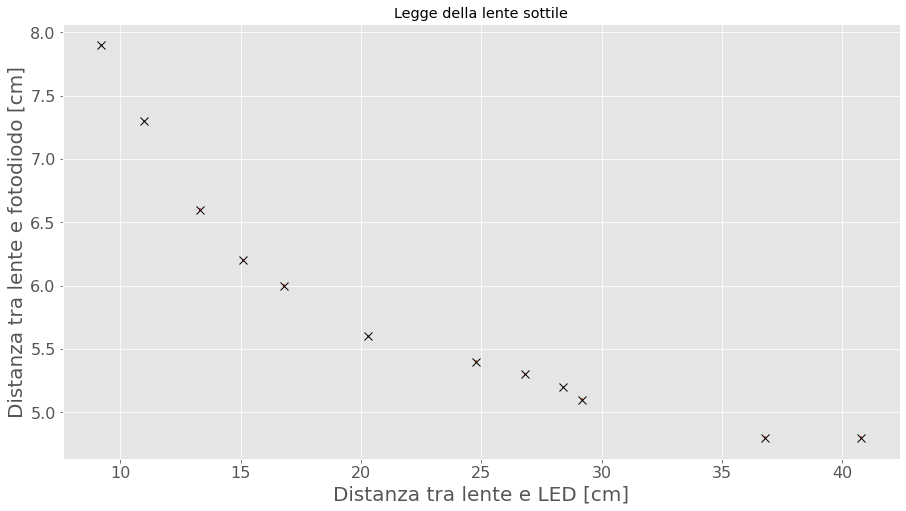

In [ ]:
# Importa librerie di lavoro

import numpy as np
from scipy import optimize as sop
import matplotlib.pyplot as plt
import pandas as pd

# Importa i dati

filename = 'https://github.com/nikitodos/UniPV_Physics_Lab_3/raw/main/05_LED_LENS/NewData/pq.csv'   # Puoi anche inserire LED_LENS_7_CM.CSV

data = pd.read_csv(filename)

x=data['p'].to_numpy()
I=data['q'].to_numpy()

print(' ')

# Plot dati

plt.figure(figsize=[15,8])
plt.title('Legge della lente sottile')
plt.xlabel('Distanza tra lente e LED [cm]', fontsize=20)
plt.ylabel('Distanza tra lente e fotodiodo [cm]', fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True)
plt.errorbar(x*100,I*100,yerr=0.01,xerr=0.01,linestyle="")
plt.plot(x*100,I*100,'x',markersize=8,color="black")
plt.style.use("ggplot")

In [ ]:
# Definisci funzione di fit

def lenti_sottili(x, x_0, y_0, f):
    I=1/(1/f - 1/(x + x_0)) - y_0
    return I

# Fit dei dati

x_0_min, x_0_max = 0.01, 0.07
y_0_min, y_0_max = 0.005, 0.02
f_min, f_max = 0.03, 0.06
min, max = [x_0_min, y_0_min, f_min], [x_0_max, y_0_max, f_max]
bounds = [min, max]
ndata = len(x)

popt, pcov = sop.curve_fit(lenti_sottili, x, I, bounds=bounds)
x_0_fit = popt[0]
y_0_fit = popt[1]
f_fit = popt[2]
sigma = np.sqrt(ndata*np.diag(pcov))

print(' ')

print('Valore fit per offset di distanza lente-LED:         x0_fit = (', np.format_float_scientific(x_0_fit,precision=2), '±',np.format_float_scientific(sigma[0],precision=1), ") m")
print('Valore fit per offset di distanza lente-fotodiodo:   y0_fit = (', np.format_float_scientific(y_0_fit,precision=2), '±',np.format_float_scientific(sigma[1],precision=1), ") m")
print('Valore fit per la distanza focale f della lente:     f_fit  = (', np.format_float_scientific(f_fit,precision=2),   '±',np.format_float_scientific(sigma[2],precision=1), ") m")

print(' ')

 
Valore fit per offset di distanza lente-LED:         x0_fit = ( 4.57e-02 ± 3.3e-02 ) m
Valore fit per offset di distanza lente-fotodiodo:   y0_fit = ( 1.68e-02 ± 1.3e-02 ) m
Valore fit per la distanza focale f della lente:     f_fit  = ( 5.66e-02 ± 9.6e-03 ) m
 


### Parte 3 - Due lenti

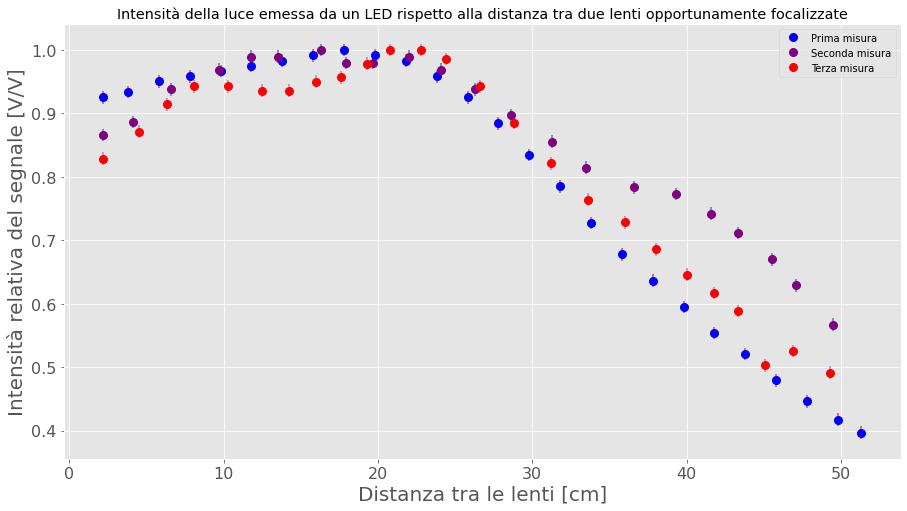

In [ ]:
# Importa librerie di lavoro

import numpy as np
from scipy import optimize as sop
import matplotlib.pyplot as plt
import pandas as pd

# Importa i dati

filename = 'https://raw.githubusercontent.com/nikitodos/UniPV_Physics_Lab_3/main/05_LED_LENS/NewData/collimazione1.csv'
data = pd.read_csv(filename)

x1=data['Distanza'].to_numpy()*100  # Centimetri
I1=data['Intensità'].to_numpy()     # Volt
I1=I1/np.amax(I1)                   # Intensità relativa adimensionale

filename = 'https://raw.githubusercontent.com/nikitodos/UniPV_Physics_Lab_3/main/05_LED_LENS/NewData/collimazione2.csv'
data = pd.read_csv(filename)

x2=data['Distanza'].to_numpy()*100  # Centimetri
I2=data['Intensità'].to_numpy()     # Volt
I2=I2/np.amax(I2)                   # Intensità relativa adimensionale

filename = 'https://raw.githubusercontent.com/nikitodos/UniPV_Physics_Lab_3/main/05_LED_LENS/NewData/collimazione3.csv'
data = pd.read_csv(filename)

x3=data['Distanza'].to_numpy()*100  # Centimetri
I3=data['Intensità'].to_numpy()     # Volt
I3=I3/np.amax(I3)                   # Intensità relativa adimensionale

# Plot dati sperimentali

plt.figure(figsize=[15,8])
plt.xlabel('Distanza tra le lenti [cm]', fontsize=20)
plt.ylabel('Intensità relativa del segnale [V/V]', fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True)
plt.errorbar(x1,I1,yerr=0.01,xerr=0.1,linestyle="")
plt.errorbar(x2,I2,yerr=0.01,xerr=0.1,linestyle="")
plt.errorbar(x3,I3,yerr=0.01,xerr=0.1,linestyle="")
plt.plot(x1,I1,'o',markersize=8,color="blue",label="Prima misura")
plt.plot(x2,I2,'o',markersize=8,color="purple",label="Seconda misura")
plt.plot(x3,I3,'o',markersize=8,color="red",label="Terza misura")
plt.title('Intensità della luce emessa da un LED rispetto alla distanza tra due lenti opportunamente focalizzate')
plt.style.use("ggplot")
plt.legend()

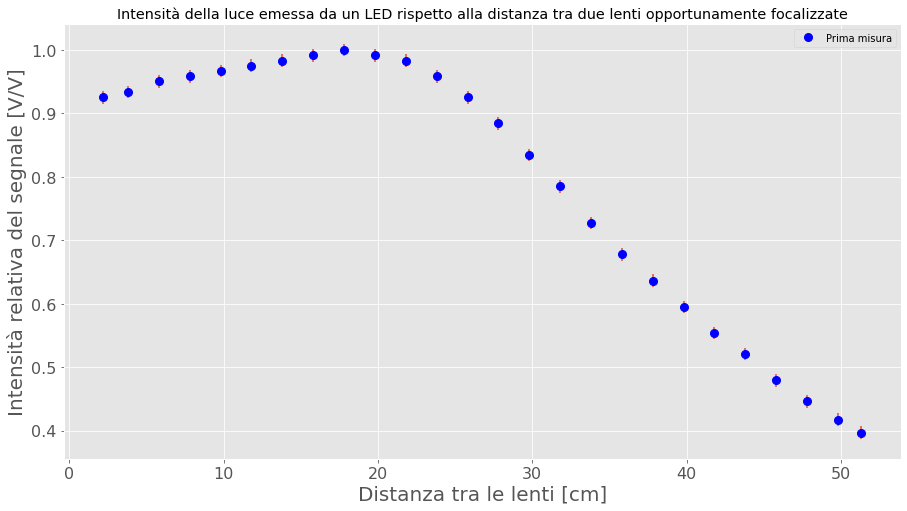

In [ ]:
# Plot dati sperimentali

plt.figure(figsize=[15,8])
plt.xlabel('Distanza tra le lenti [cm]', fontsize=20)
plt.ylabel('Intensità relativa del segnale [V/V]', fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True)
plt.errorbar(x1,I1,yerr=0.01,xerr=0.1,linestyle="")
plt.plot(x1,I1,'o',markersize=8,color="blue",label="Prima misura")
plt.title('Intensità della luce emessa da un LED rispetto alla distanza tra due lenti opportunamente focalizzate')
plt.style.use("ggplot")
plt.legend()

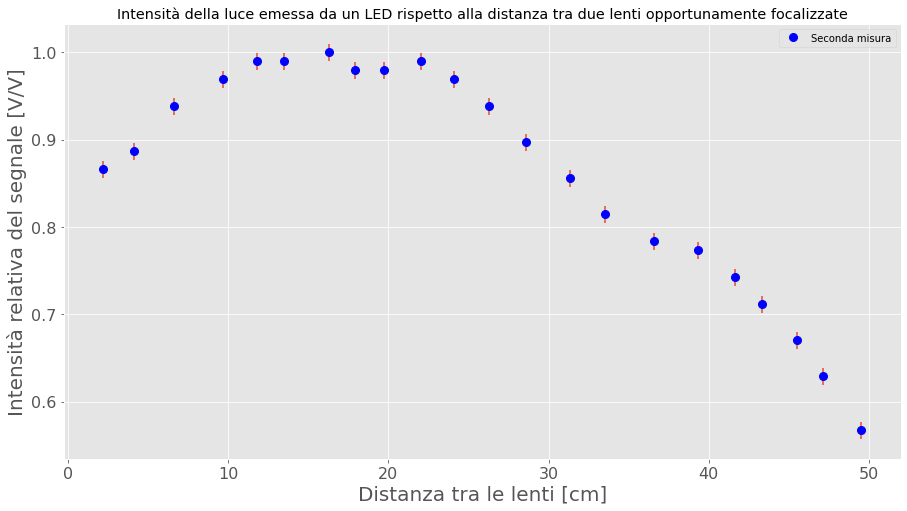

In [ ]:
# Plot dati sperimentali

plt.figure(figsize=[15,8])
plt.xlabel('Distanza tra le lenti [cm]', fontsize=20)
plt.ylabel('Intensità relativa del segnale [V/V]', fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True)
plt.errorbar(x2,I2,yerr=0.01,xerr=0.1,linestyle="")
plt.plot(x2,I2,'o',markersize=8,color="blue",label="Seconda misura")
plt.title('Intensità della luce emessa da un LED rispetto alla distanza tra due lenti opportunamente focalizzate')
plt.style.use("ggplot")
plt.legend()

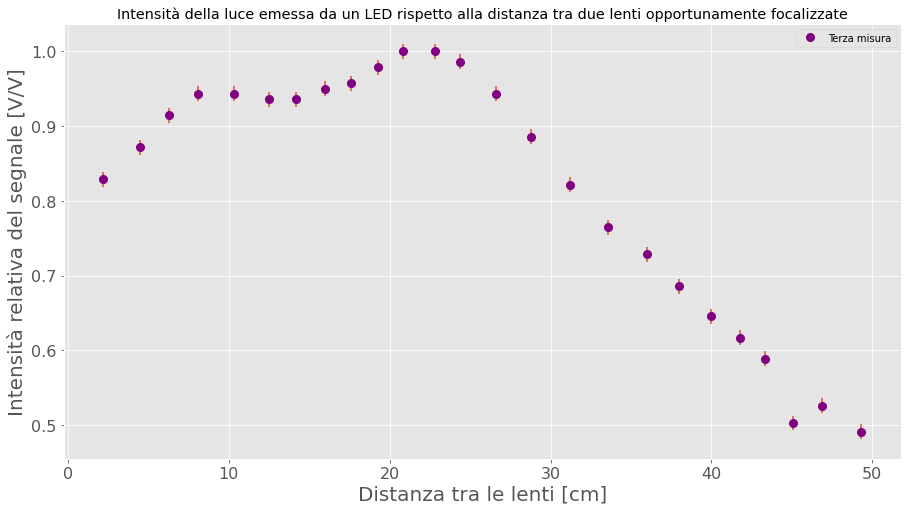

In [ ]:
# Plot dati sperimentali

plt.figure(figsize=[15,8])
plt.xlabel('Distanza tra le lenti [cm]', fontsize=20)
plt.ylabel('Intensità relativa del segnale [V/V]', fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True)
plt.errorbar(x3,I3,yerr=0.01,xerr=0.1,linestyle="")
plt.plot(x3,I3,'o',markersize=8,color="purple",label="Terza misura")
plt.title('Intensità della luce emessa da un LED rispetto alla distanza tra due lenti opportunamente focalizzate')
plt.style.use("ggplot")
plt.legend()

## Discussione dei risultati e conclusioni

Dalla prima parte emerge effettivamente una proporzionalità quadratica inversa tra la distanza tra sorgente e rivelatore e intensità del fascio stesso, ottenuta con accordo molto buono con i dati di fit.

Dalla seconda parte della prova, è degno di nota l'accordo tra la lunghezza focale calcolata mediante la legge della lente e il valore noto a priori, che discosta di poco più di mezzo centimetro. Inoltre, la presenza di due lenti e l'introduzione di un secondo parametro di offset, necessario per correggere le misure di distanza prese dalla base di ciascun dispositivo elettronico, rende la stima di $x_0$ e $y_0$ nella seconda parte della prova più accurata.

Infine, risulta di grande interesse il fatto che dalla terza prova si ottiene una buona collimazione per brevi distanze; per quelle grandi, invece, la natura non puntiforme della sorgente viene a manifestarsi maggiormente, traducendosi in misure più spurie. Quel che ne risulta è una decrescita dell'intensità del fascio luminoso.

L'aspetto probabilmente più complesso della prova è stato proprio l'ottenimento del fascio collimato nella terza parte, che da come si è potuto constatare + stata condotta con più tentativi.

Per i risultati ottenuti, gli scopi della prova sono considerati raggiunti con successo.